# LC Multi Outputs E2E Test - Basic Functionality on Notebook 7

- Test that LC Multi Outputs extension works properly on Notebook 7
- Multi-outputs UI verified (pin button, tabs, and output rendering)
- Verify multiple output tabs
- Verify output content changes when switching tabs
- Verify diff dialog shows differences between outputs
- Verify pinned tabs are saved and restored after notebook reload
- Verify tabs can be closed and container disappears when all tabs are closed

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000
jupyter_work_dir = '../artifacts/jupyter-work'

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpxcz26w2w


In [4]:
import re
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251226-155810',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpi96t1jyr')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1766732291.336241 seconds


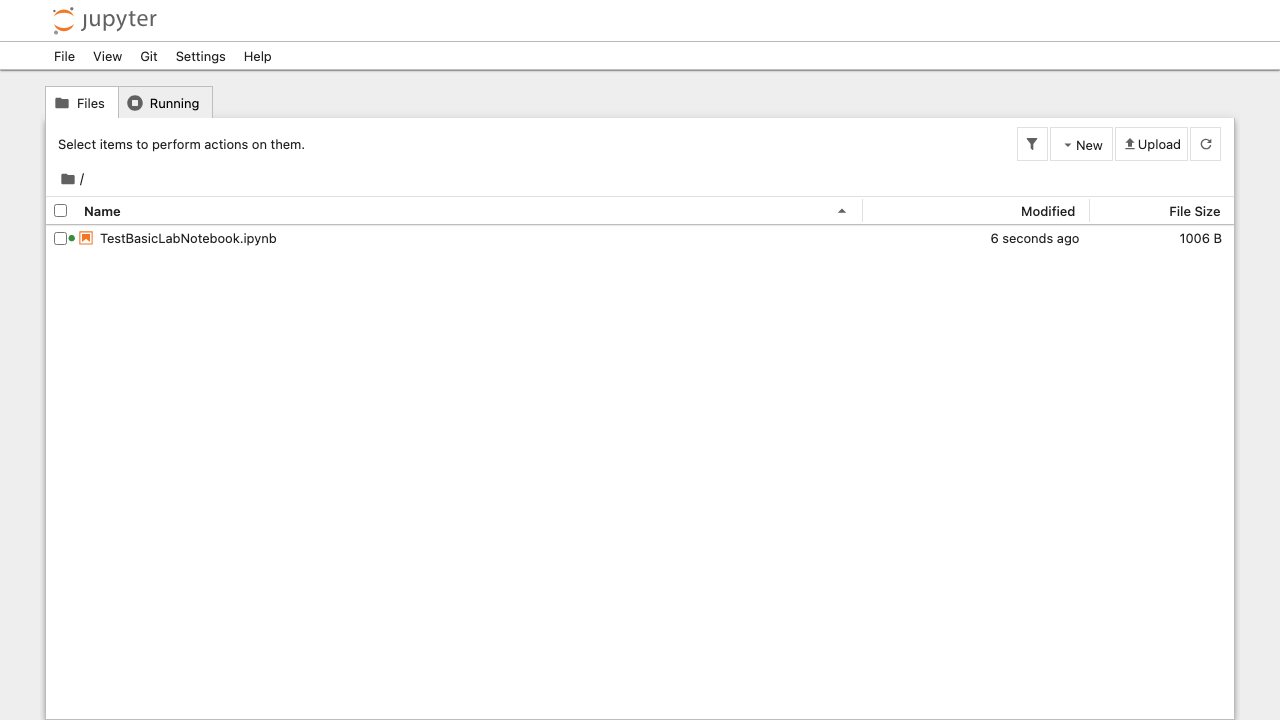

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")
    
    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Remove existing test notebook if it exists

Start epoch: 1766732293.6610198 seconds
No existing test notebook to remove


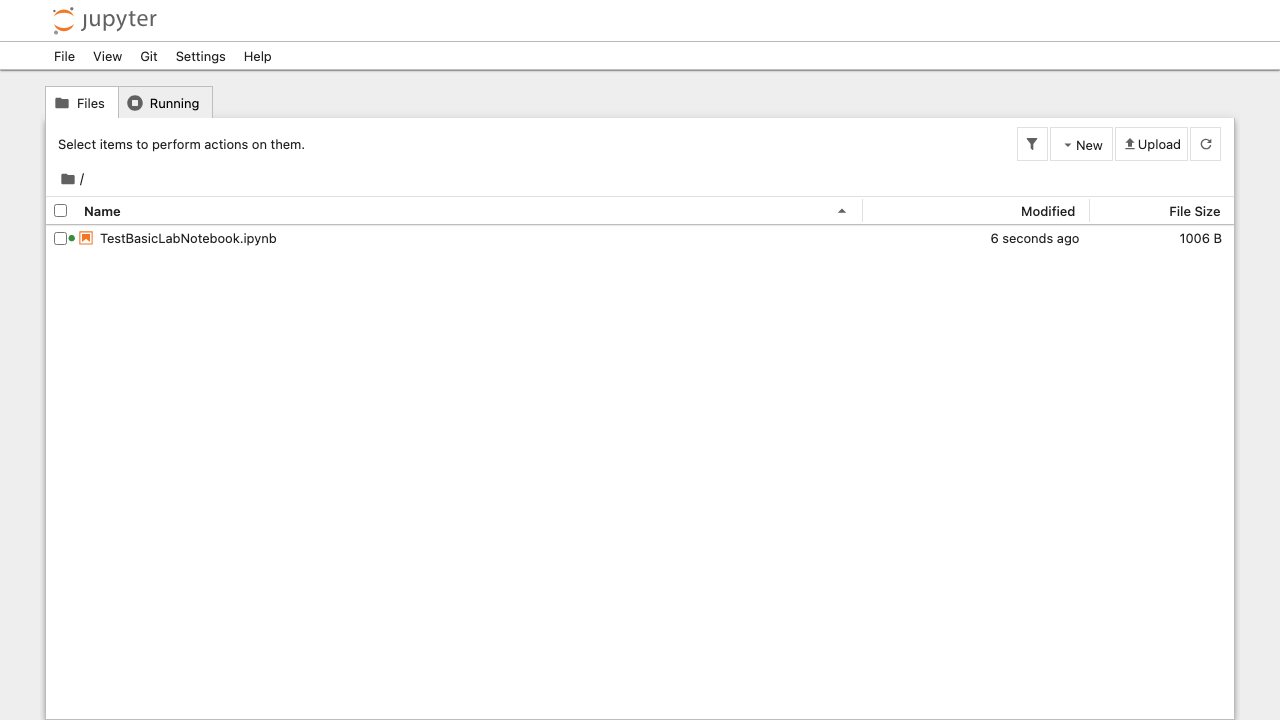

In [6]:
test_filename = "TestBasic7Notebook.ipynb"
async def _step_remove_existing_notebook(page):
    deleted = await delete_file(page, test_filename, timeout=transition_timeout)
    if deleted:
        print("✓ Removed existing test notebook")
    else:
        print("No existing test notebook to remove")

await run_pw(_step_remove_existing_notebook)

## Create a new notebook for testing multi_outputs

Start epoch: 1766732293.7830038 seconds


✓ New notebook created


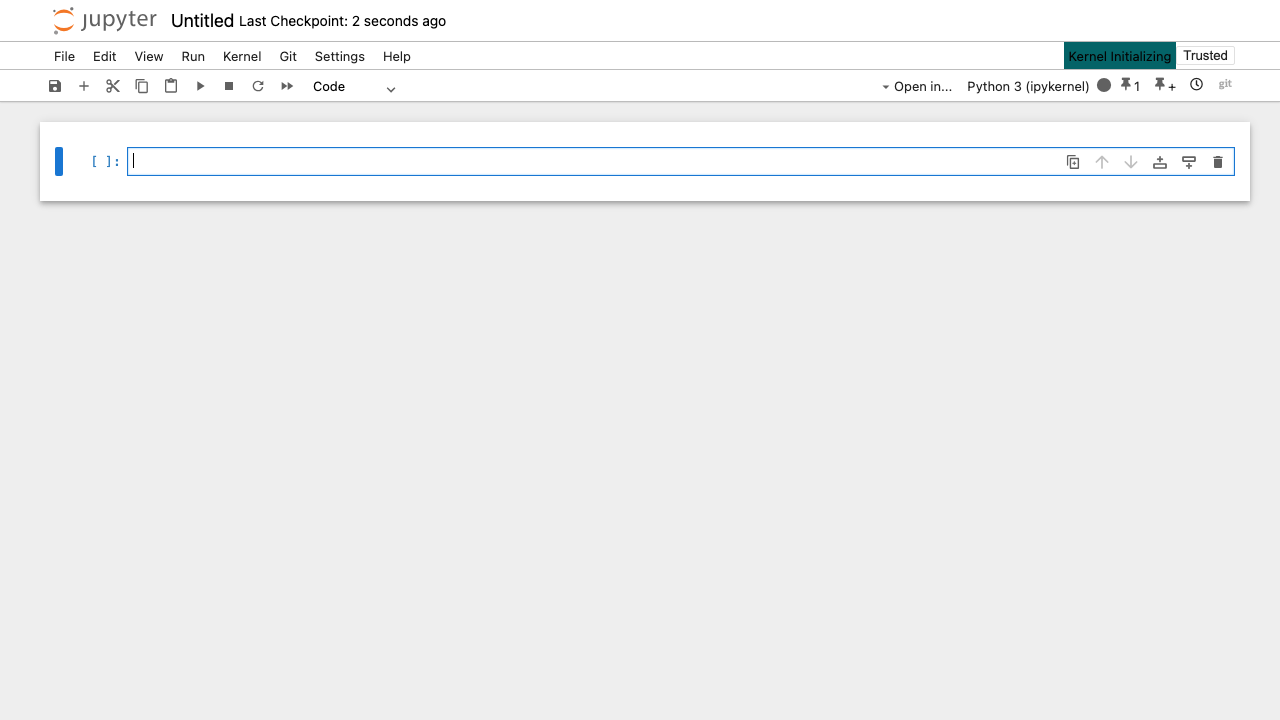

In [7]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, timeout=transition_timeout)
    print(f"✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Rename and save the notebook

Start epoch: 1766732296.8467462 seconds


✓ Notebook renamed and saved: TestBasic7Notebook.ipynb


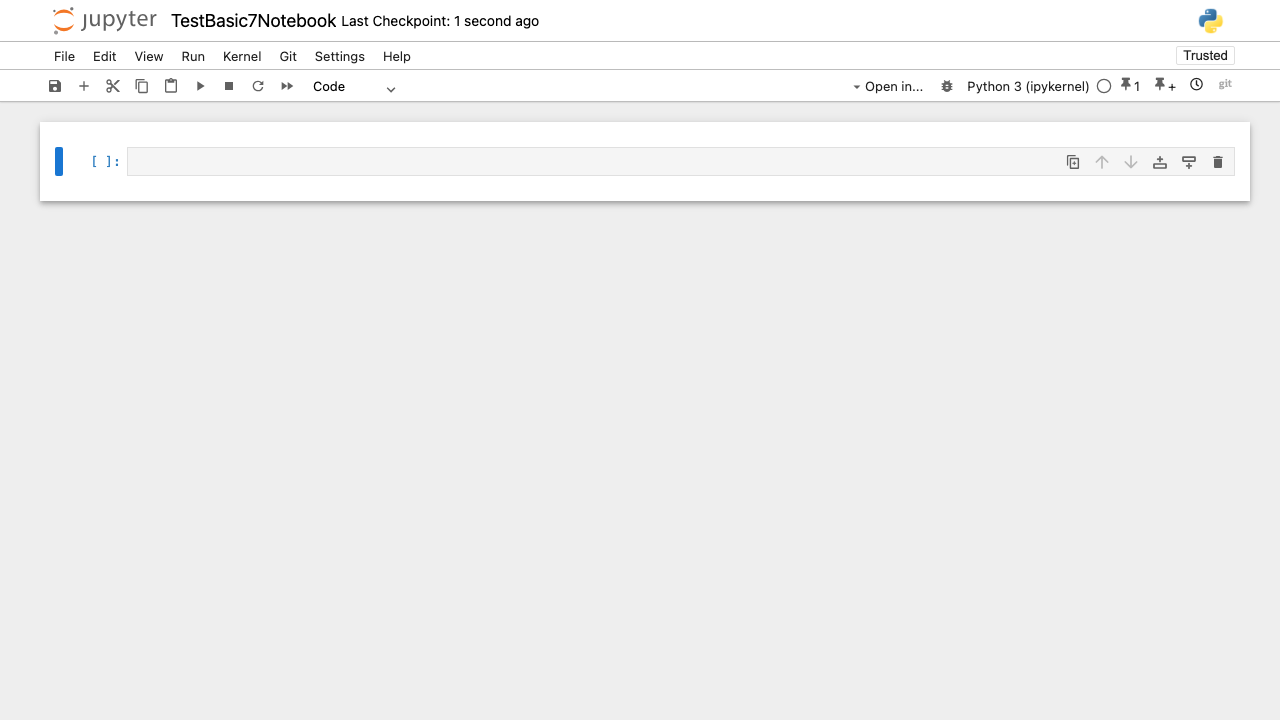

In [8]:
async def _step_rename_and_save(page):
    # Rename the notebook
    await rename_notebook(page, test_filename, timeout=transition_timeout)
    
    # Save the notebook
    await save_notebook(page)
    
    print(f"✓ Notebook renamed and saved: {test_filename}")

await run_pw(_step_rename_and_save)

## Multi-outputs UI verified (pin button, tabs, and output rendering)

Start epoch: 1766732298.6859431 seconds


✓ Multi-outputs UI verified (pin button, tabs, and output rendering)


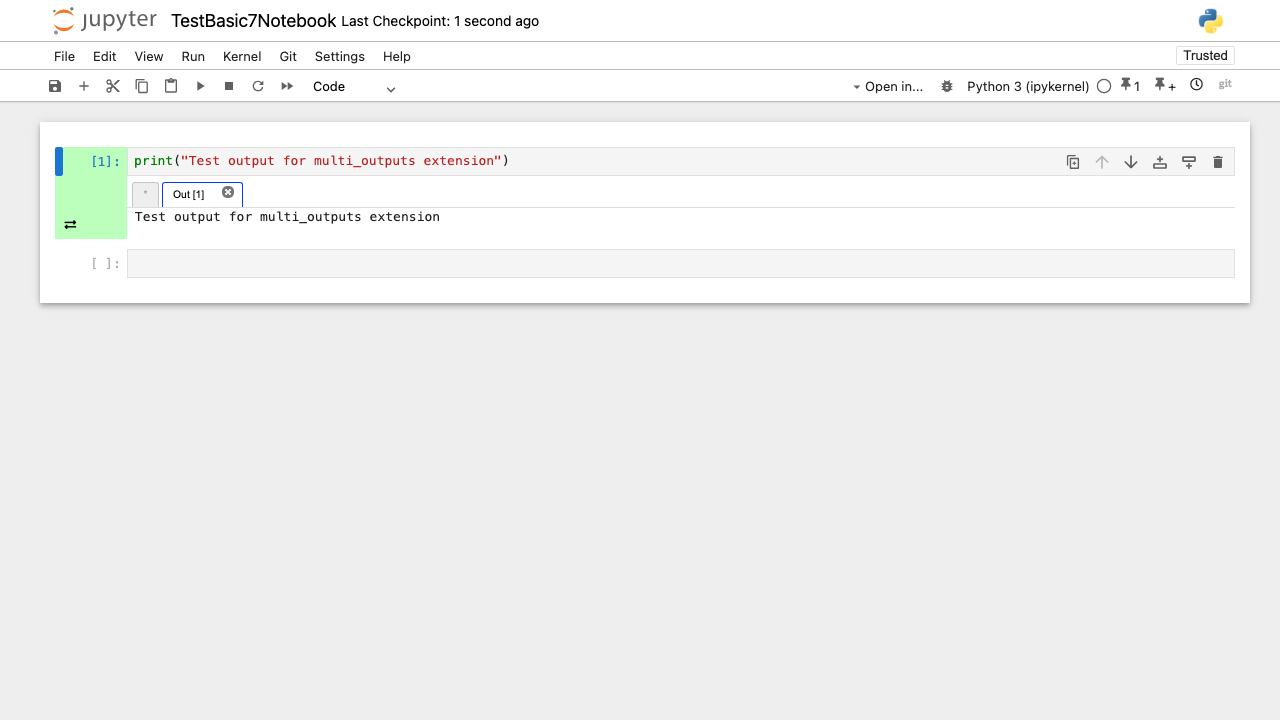

In [9]:
async def _step_verify_multi_outputs_ui(page):
    # Use a simple print statement that will show in the output area
    await set_cell(page, 0, "code", 'print("Test output for multi_outputs extension")', timeout=transition_timeout)

    # Execute the cell
    await run_cell(page, 0, True, timeout=transition_timeout)
        
    # Wait a bit for the multi_outputs extension to add its UI elements
    await page.wait_for_timeout(1000)

    # Get the first cell
    await select_cell(page, 0, timeout=transition_timeout)
    cell = await get_cell(page, 0, timeout=transition_timeout)

    # Click pin button on the first cell
    output_ui = cell.locator('.multi-outputs-ui')
    pin_button = output_ui.locator('button')
    await expect(pin_button).to_be_visible(timeout=transition_timeout)
    await pin_button.click()

    # Check that there are tabs
    multi_outputs_widget = cell.locator('.multi-output-widget')
    await expect(multi_outputs_widget).to_be_visible(timeout=transition_timeout)
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    await expect(multi_output_tabs).to_be_visible(timeout=transition_timeout)

    # Check that there are current tab and the first tab
    current_tab = multi_output_tabs.locator('li#tab-output-current')
    await expect(current_tab).to_be_visible(timeout=transition_timeout)
    first_tab = multi_output_tabs.locator('li#tab-output-1')
    await expect(first_tab).to_be_visible(timeout=transition_timeout)

    # Check that the output is rendered properly
    output_wrapper = multi_outputs_widget.locator('.multi-output-wrapper#output-1')
    await expect(output_wrapper).to_be_visible(timeout=transition_timeout)
    output_text = await output_wrapper.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Test output" in output_text, f"Expected output not found. Got: {output_text}"

    print("✓ Multi-outputs UI verified (pin button, tabs, and output rendering)")


await run_pw(_step_verify_multi_outputs_ui)

## Verify multiple output tabs

Start epoch: 1766732305.6600718 seconds


✓ Multiple executions and pinning verified (4 tabs: current + Out[1-3])


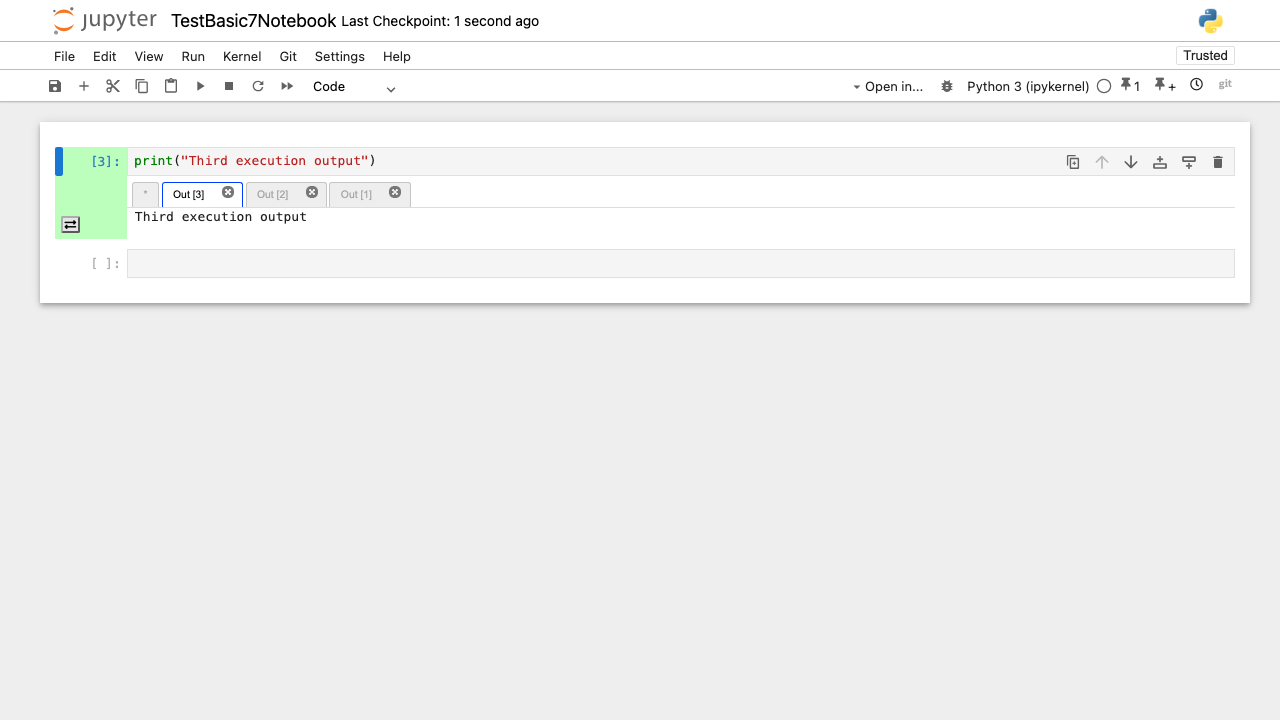

In [10]:
async def _step_multiple_executions_and_pinning(page):
    # Change the cell content and execute again
    await set_cell(page, 0, "code", 'print("Second execution output")', timeout=transition_timeout)
    await run_cell(page, 0, True, timeout=transition_timeout)
    await page.wait_for_timeout(1000)

    # Get the first cell
    await select_cell(page, 0, timeout=transition_timeout)
    cell = await get_cell(page, 0, timeout=transition_timeout)
    
    # Pin the second output
    output_ui = cell.locator('.multi-outputs-ui')
    pin_button = output_ui.locator('button')
    await pin_button.click()
    
    # Verify that Out[2] tab is now visible
    multi_outputs_widget = cell.locator('.multi-output-widget')
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    second_tab = multi_output_tabs.locator('li#tab-output-2')
    await expect(second_tab).to_be_visible(timeout=transition_timeout)
    
    # Execute and pin a third time
    await set_cell(page, 0, "code", 'print("Third execution output")', timeout=transition_timeout)
    await run_cell(page, 0, True, timeout=transition_timeout)
    await page.wait_for_timeout(1000)
    await select_cell(page, 0, timeout=transition_timeout)
    await pin_button.click()
    
    # Verify that Out[3] tab is now visible
    third_tab = multi_output_tabs.locator('li#tab-output-3')
    await expect(third_tab).to_be_visible(timeout=transition_timeout)
    
    # Verify all tabs are present (current, 1, 2, 3)
    current_tab = multi_output_tabs.locator('li#tab-output-current')
    first_tab = multi_output_tabs.locator('li#tab-output-1')
    await expect(current_tab).to_be_visible(timeout=transition_timeout)
    await expect(first_tab).to_be_visible(timeout=transition_timeout)
    await expect(second_tab).to_be_visible(timeout=transition_timeout)
    await expect(third_tab).to_be_visible(timeout=transition_timeout)
    
    print("✓ Multiple executions and pinning verified (4 tabs: current + Out[1-3])")

await run_pw(_step_multiple_executions_and_pinning)

## Verify output content changes when switching tabs

Start epoch: 1766732315.936459 seconds


✓ Tab switching verified (all tabs show correct output content)


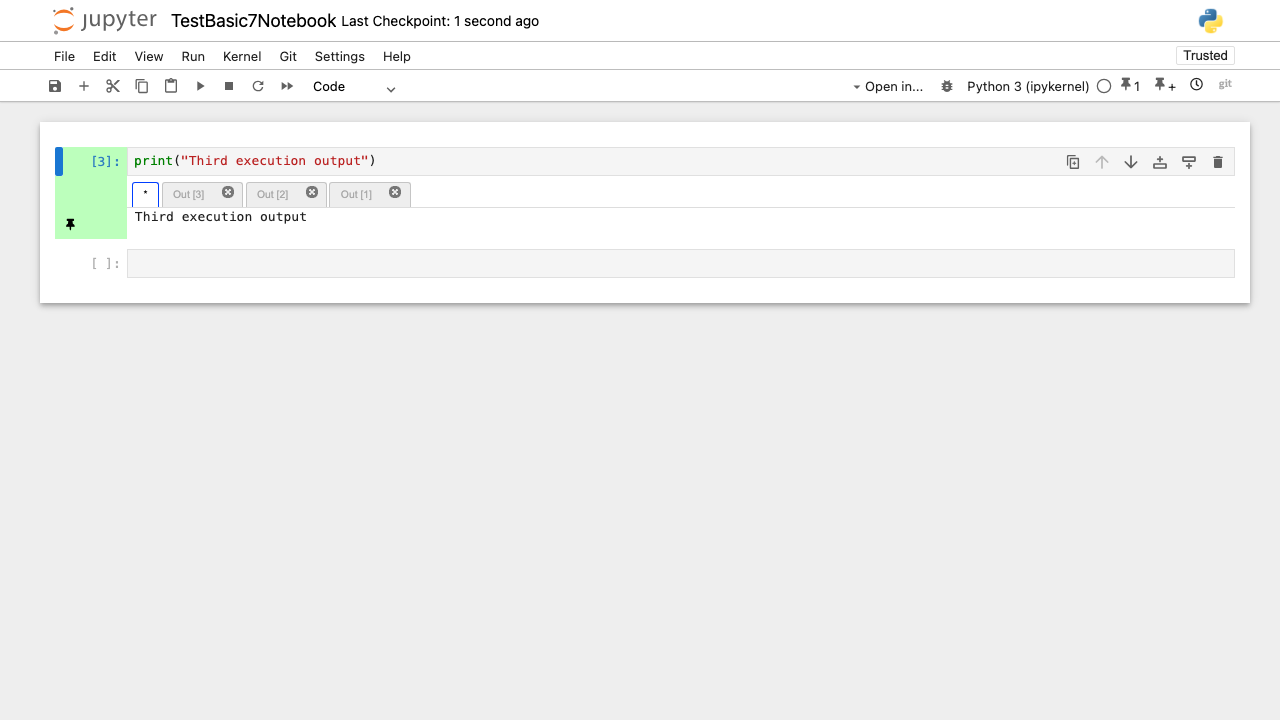

In [11]:
async def _step_tab_switching(page):
    # Get the first cell
    cell = await get_cell(page, 0, timeout=transition_timeout)
    multi_outputs_widget = cell.locator('.multi-output-widget')
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    
    # Click on Out[1] tab and verify its content
    first_tab = multi_output_tabs.locator('li#tab-output-1')
    await first_tab.click()
    
    output_wrapper_1 = multi_outputs_widget.locator('.multi-output-wrapper#output-1')
    await expect(output_wrapper_1).to_be_visible(timeout=transition_timeout)
    output_text_1 = await output_wrapper_1.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Test output for multi_outputs extension" in output_text_1, f"Expected first output not found. Got: {output_text_1}"
    
    # Click on Out[2] tab and verify its content
    second_tab = multi_output_tabs.locator('li#tab-output-2')
    await second_tab.click()
    
    output_wrapper_2 = multi_outputs_widget.locator('.multi-output-wrapper#output-2')
    await expect(output_wrapper_2).to_be_visible(timeout=transition_timeout)
    output_text_2 = await output_wrapper_2.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Second execution output" in output_text_2, f"Expected second output not found. Got: {output_text_2}"
    
    # Click on Out[3] tab and verify its content
    third_tab = multi_output_tabs.locator('li#tab-output-3')
    await third_tab.click()
    
    output_wrapper_3 = multi_outputs_widget.locator('.multi-output-wrapper#output-3')
    await expect(output_wrapper_3).to_be_visible(timeout=transition_timeout)
    output_text_3 = await output_wrapper_3.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Third execution output" in output_text_3, f"Expected third output not found. Got: {output_text_3}"
    
    # Click on Current Output tab and verify it shows the latest output
    current_tab = multi_output_tabs.locator('li#tab-output-current')
    await current_tab.click()
    
    output_wrapper_current = multi_outputs_widget.locator('.multi-output-wrapper#output-current')
    await expect(output_wrapper_current).to_be_visible(timeout=transition_timeout)
    output_text_current = await output_wrapper_current.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Third execution output" in output_text_current, f"Expected current output not found. Got: {output_text_current}"
    
    print("✓ Tab switching verified (all tabs show correct output content)")

await run_pw(_step_tab_switching)

## Verify diff dialog shows differences between outputs

Start epoch: 1766732316.263345 seconds



Concatenated highlighted text: 'multi_outputs'
✓ Diff functionality verified (views show correct text, search highlights work)


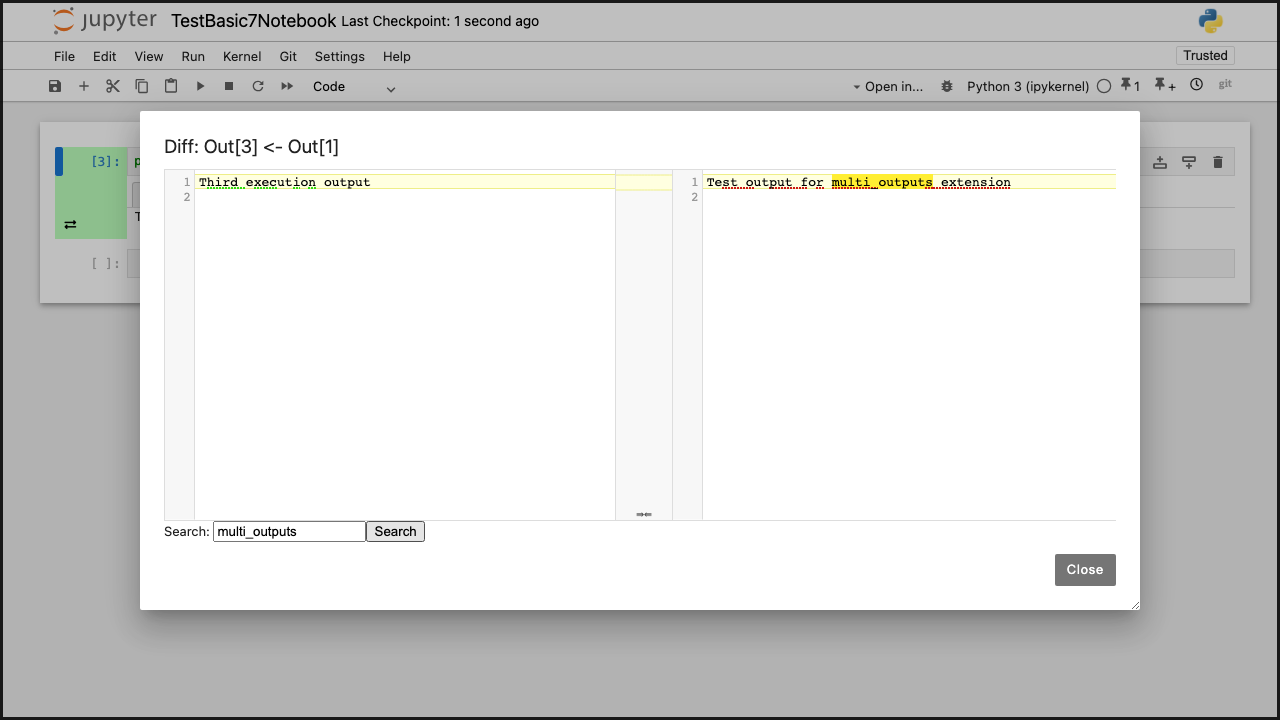

In [12]:
async def _step_diff_functionality(page):
    # Get the first cell
    cell = await get_cell(page, 0, timeout=transition_timeout)
    multi_outputs_widget = cell.locator('.multi-output-widget')
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    
    # Click on Out[1] tab to select it
    first_tab = multi_output_tabs.locator('li#tab-output-1')
    await first_tab.click()
    
    # Click the diff button for Out[1]
    output_wrapper_1 = multi_outputs_widget.locator('.multi-output-wrapper#output-1')
    diff_button = output_wrapper_1.locator('.multi-outputs-diff-ui').locator('button')
    await expect(diff_button).to_be_visible(timeout=transition_timeout)
    await diff_button.click()
    
    # Find the diff dialog containing "Diff: Out[3] <- Out[1]"
    # Current output is Out[3], comparing with Out[1]
    diff_dialog = page.locator('dialog').filter(has_text='Diff: Out[3] <- Out[1]')
    await expect(diff_dialog).to_be_visible(timeout=transition_timeout)
    
    # Verify left view (Out[3]) shows the current output text
    left_view = diff_dialog.locator('.CodeMirror').first
    left_text = await left_view.text_content()
    assert "Third execution output" in left_text, f"Expected left view text not found. Got: {left_text}"
    
    # Verify right view (Out[1]) shows the first output text
    right_view = diff_dialog.locator('.CodeMirror').nth(1)
    right_text = await right_view.text_content()
    assert "Test output for multi_outputs extension" in right_text, f"Expected right view text not found. Got: {right_text}"
    
    # Test search functionality with "multi_outputs"
    search_input = diff_dialog.locator('input[type="text"]')
    await expect(search_input).to_be_visible(timeout=transition_timeout)
    await search_input.fill("multi_outputs")
    
    # Click the Search button (input element)
    search_button = diff_dialog.locator('input[value="Search"]')
    await expect(search_button).to_be_visible(timeout=transition_timeout)
    await search_button.click()
    
    # Collect all search-highlight elements and concatenate their text
    search_highlight = diff_dialog.locator('.search-highlight')
    elements = await search_highlight.all()
    
    # Concatenate all highlighted text
    highlighted_text = ""
    for elem in elements:
        text = await elem.text_content()
        highlighted_text += text
    
    print(f"\nConcatenated highlighted text: '{highlighted_text}'")
    
    # Verify that the concatenated text equals "multi_outputs"
    assert highlighted_text == "multi_outputs", f"Expected 'multi_outputs' but got '{highlighted_text}'"
    
    print("✓ Diff functionality verified (views show correct text, search highlights work)")

await run_pw(_step_diff_functionality)

## Close diff dialog

Start epoch: 1766732316.71364 seconds
✓ Diff dialog closed successfully


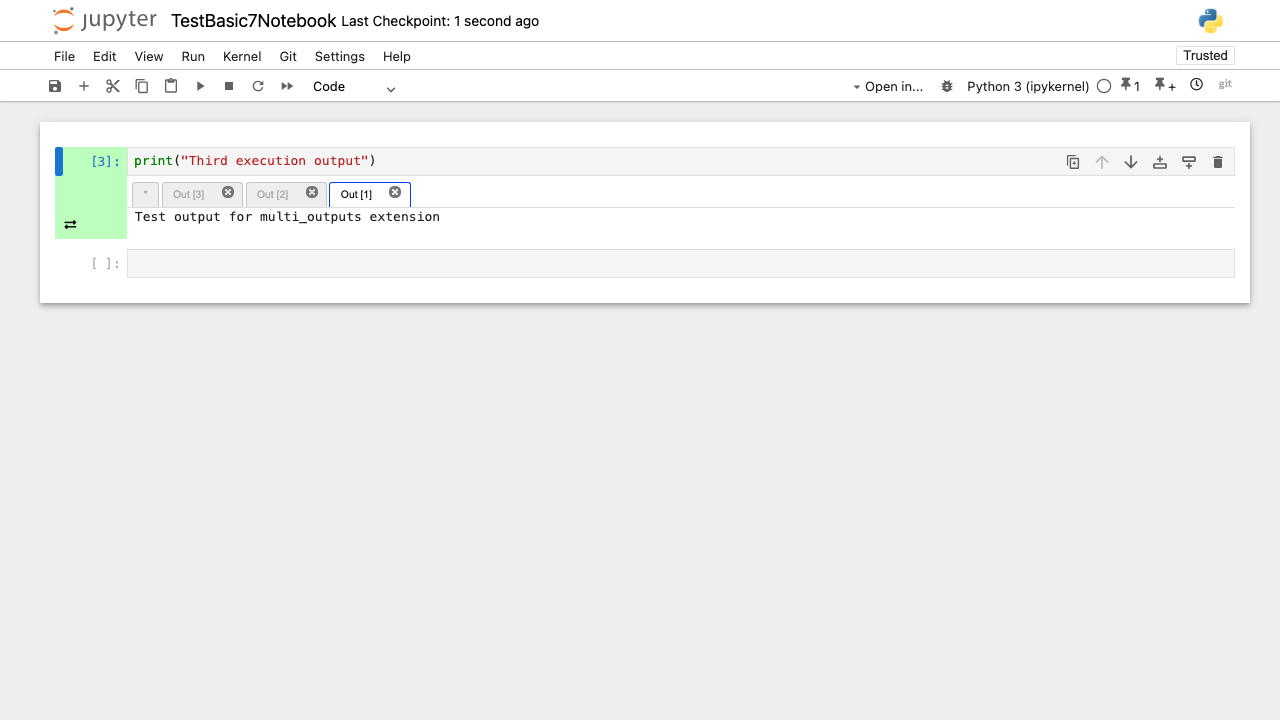

In [13]:
async def _step_close_diff_dialog(page):
    # Close the diff dialog
    diff_dialog = page.locator('dialog').first
    close_button = diff_dialog.get_by_text('Close')
    await expect(close_button).to_be_visible(timeout=transition_timeout)
    await close_button.click()
    
    # Verify the dialog is closed
    await expect(diff_dialog).not_to_be_visible()
    
    print("✓ Diff dialog closed successfully")

await run_pw(_step_close_diff_dialog)

## Verify pinned tabs are saved and restored after notebook reload

Start epoch: 1766732316.8600771 seconds


✓ Notebook saved


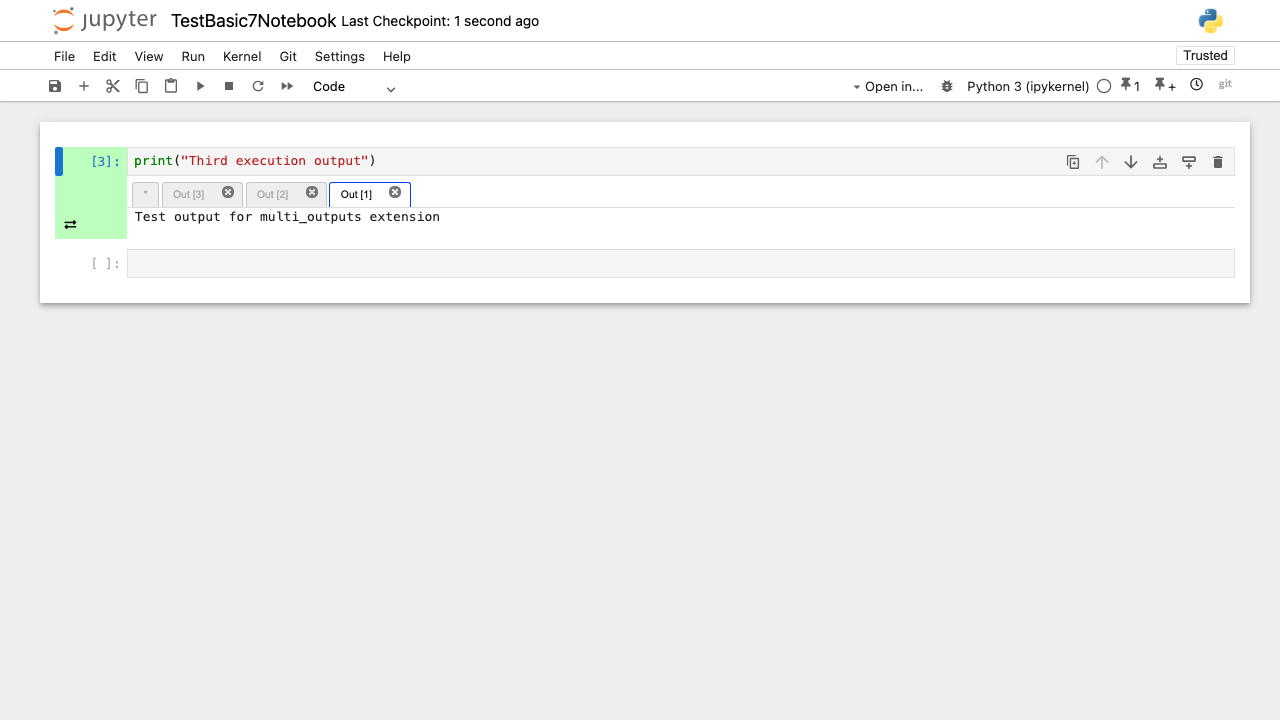

In [14]:
async def _step_save_notebook_for_reload(page):
    # Save the notebook
    await save_notebook(page)
    print("✓ Notebook saved")

await run_pw(_step_save_notebook_for_reload)

In [15]:
# Close the notebook page using the helper function
# This will automatically return to the previous page (tree_page)
await close_latest_page()

print("✓ Notebook closed")

✓ Notebook closed


Start epoch: 1766732318.039146 seconds


✓ Notebook reopened: TestBasic7Notebook.ipynb


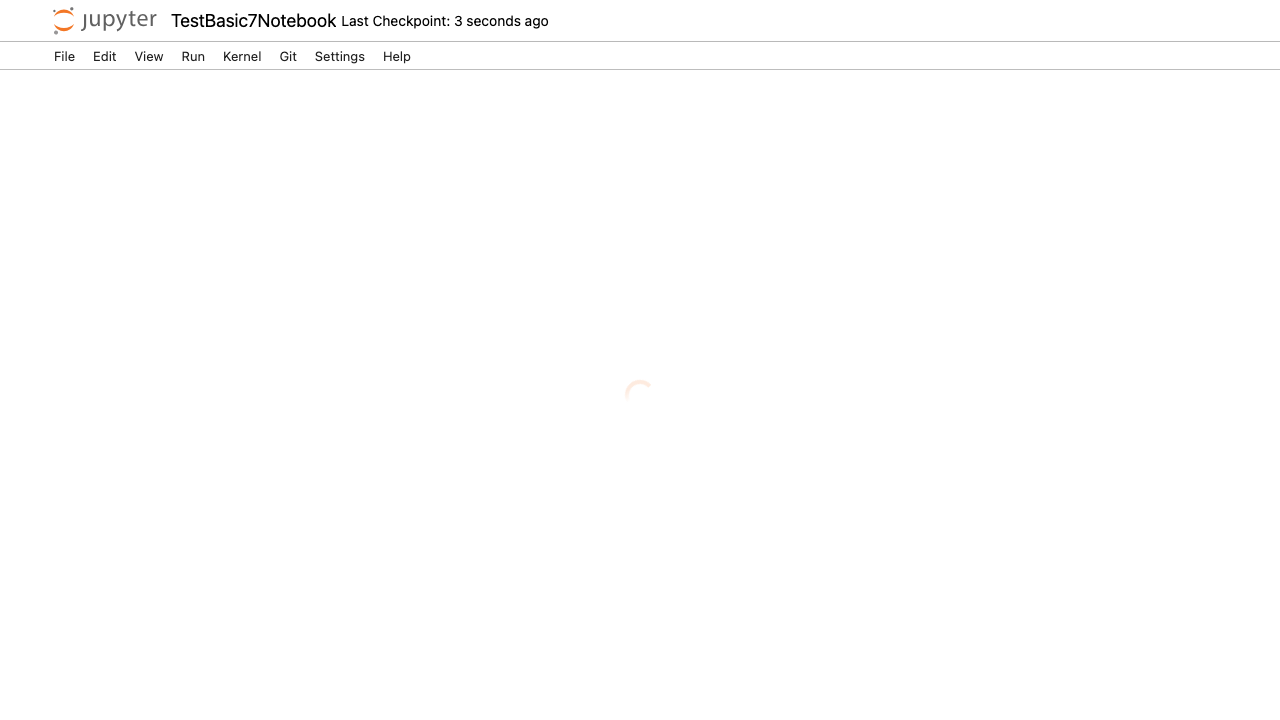

In [16]:
async def _step_reopen_notebook(page):
    # After close_latest_page(), the current page is automatically tree_page
    # Double-click on the notebook file to open it in a new tab
    
    file_item = page.locator('.jp-DirListing-content li span.jp-DirListing-itemText').filter(has_text=test_filename)
    await expect(file_item).to_be_visible(timeout=transition_timeout)
    
    # Wait for new page when double-clicking the file
    async with page.context.expect_page() as new_page_info:
        await file_item.dblclick()
    
    # Get the reopened notebook page
    reopened_page = await new_page_info.value
    
    # Wait for notebook to be ready
    await expect(reopened_page.locator('.jp-Cell.jp-CodeCell').first).to_be_visible(timeout=transition_timeout)
    
    print(f"✓ Notebook reopened: {test_filename}")
    
    return reopened_page

await run_pw(_step_reopen_notebook)

Start epoch: 1766732319.92517 seconds
✓ All tabs restored (Current Output, Out[1], Out[2], Out[3])
✓ Out[1] content preserved


✓ Out[2] content preserved
✓ Out[3] content preserved
✓ Persistence verified (all pinned tabs and their contents are restored)


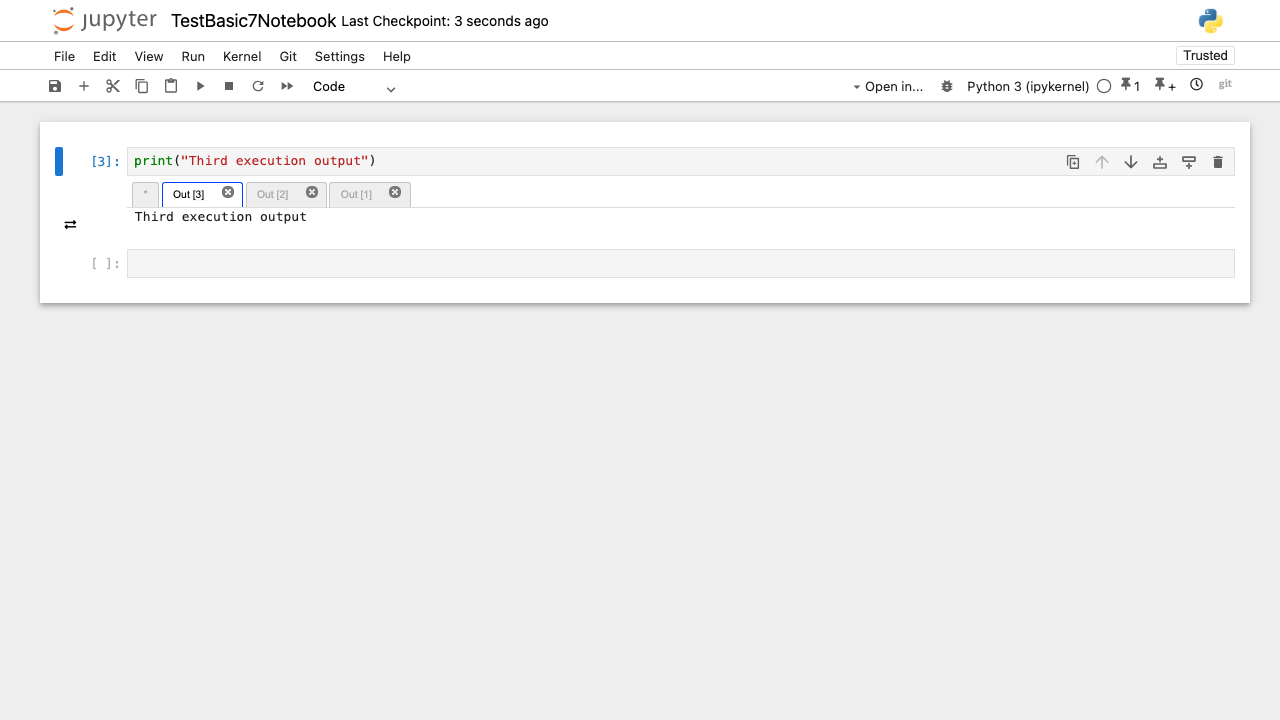

In [17]:
async def _step_verify_tabs_restored(page):
    # Get the first cell from the reopened notebook
    cell = await get_cell(page, 0, timeout=transition_timeout)
    multi_outputs_widget = cell.locator('.multi-output-widget')
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    
    # Verify that the tabs container is visible
    await expect(multi_outputs_widget).to_be_visible(timeout=transition_timeout)
    await expect(multi_output_tabs).to_be_visible(timeout=transition_timeout)
    
    # Verify all tabs are restored (Current Output, Out[1], Out[2], Out[3])
    current_tab = multi_output_tabs.locator('li#tab-output-current')
    await expect(current_tab).to_be_visible()
    
    tab_output_1 = multi_output_tabs.locator('li#tab-output-1')
    await expect(tab_output_1).to_be_visible()
    
    tab_output_2 = multi_output_tabs.locator('li#tab-output-2')
    await expect(tab_output_2).to_be_visible()
    
    tab_output_3 = multi_output_tabs.locator('li#tab-output-3')
    await expect(tab_output_3).to_be_visible()
    
    print("✓ All tabs restored (Current Output, Out[1], Out[2], Out[3])")
    
    # Verify the content of each pinned tab is preserved
    # Click on Out[1] and verify its content
    await tab_output_1.click()
    output_wrapper_1 = multi_outputs_widget.locator('.multi-output-wrapper#output-1')
    await expect(output_wrapper_1).to_be_visible(timeout=transition_timeout)
    output_text_1 = await output_wrapper_1.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Test output for multi_outputs extension" in output_text_1, f"Expected Out[1] content not found. Got: {output_text_1}"
    print("✓ Out[1] content preserved")
    
    # Click on Out[2] and verify its content
    await tab_output_2.click()
    output_wrapper_2 = multi_outputs_widget.locator('.multi-output-wrapper#output-2')
    await expect(output_wrapper_2).to_be_visible(timeout=transition_timeout)
    output_text_2 = await output_wrapper_2.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Second execution output" in output_text_2, f"Expected Out[2] content not found. Got: {output_text_2}"
    print("✓ Out[2] content preserved")
    
    # Click on Out[3] and verify its content
    await tab_output_3.click()
    output_wrapper_3 = multi_outputs_widget.locator('.multi-output-wrapper#output-3')
    await expect(output_wrapper_3).to_be_visible(timeout=transition_timeout)
    output_text_3 = await output_wrapper_3.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Third execution output" in output_text_3, f"Expected Out[3] content not found. Got: {output_text_3}"
    print("✓ Out[3] content preserved")
    
    print("✓ Persistence verified (all pinned tabs and their contents are restored)")

await run_pw(_step_verify_tabs_restored)

## Verify tabs can be closed and container disappears when all tabs are closed

Start epoch: 1766732320.341876 seconds


✓ Out[3] tab closed
✓ Out[2] tab closed
✓ Out[1] tab closed
✓ Tabs container hidden after all pinned tabs are closed


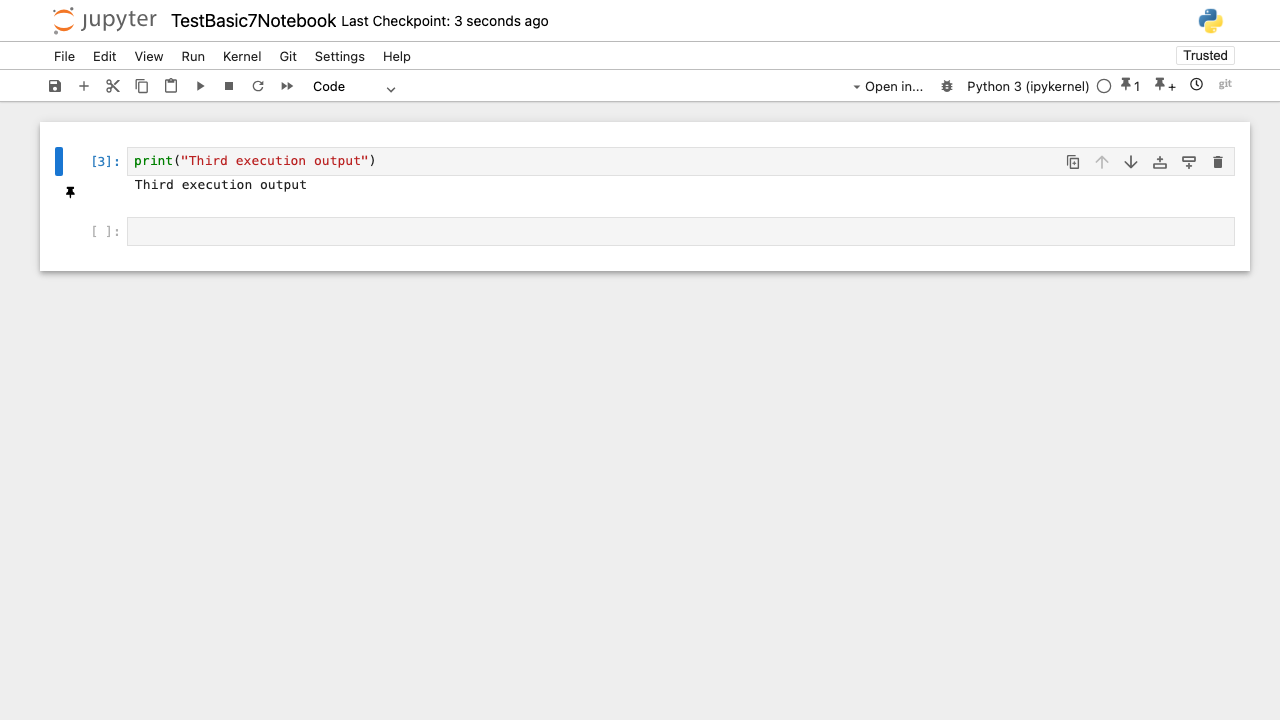

In [18]:
async def _step_tab_closing(page):
    # Get the first cell
    cell = await get_cell(page, 0, timeout=transition_timeout)
    multi_outputs_widget = cell.locator('.multi-output-widget')
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    
    # Close Out[3] tab
    tab_output_3 = multi_output_tabs.locator('li#tab-output-3')
    close_button_3 = tab_output_3.locator('button')
    await expect(close_button_3).to_be_visible(timeout=transition_timeout)
    await close_button_3.click()
    
    # Verify Out[3] tab is no longer visible
    await expect(tab_output_3).not_to_be_visible()
    print("✓ Out[3] tab closed")
    
    # Close Out[2] tab
    tab_output_2 = multi_output_tabs.locator('li#tab-output-2')
    close_button_2 = tab_output_2.locator('button')
    await expect(close_button_2).to_be_visible(timeout=transition_timeout)
    await close_button_2.click()
    
    # Verify Out[2] tab is no longer visible
    await expect(tab_output_2).not_to_be_visible()
    print("✓ Out[2] tab closed")
    
    # Close Out[1] tab (the last pinned tab)
    tab_output_1 = multi_output_tabs.locator('li#tab-output-1')
    close_button_1 = tab_output_1.locator('button')
    await expect(close_button_1).to_be_visible(timeout=transition_timeout)
    await close_button_1.click()
    
    # Verify Out[1] tab is no longer visible
    await expect(tab_output_1).not_to_be_visible()
    print("✓ Out[1] tab closed")
    
    # Verify that the tabs container is no longer visible after all pinned tabs are closed
    await expect(multi_output_tabs).not_to_be_visible()
    print("✓ Tabs container hidden after all pinned tabs are closed")

await run_pw(_step_tab_closing)

## Save the notebook

Start epoch: 1766732320.655636 seconds


✓ Notebook saved


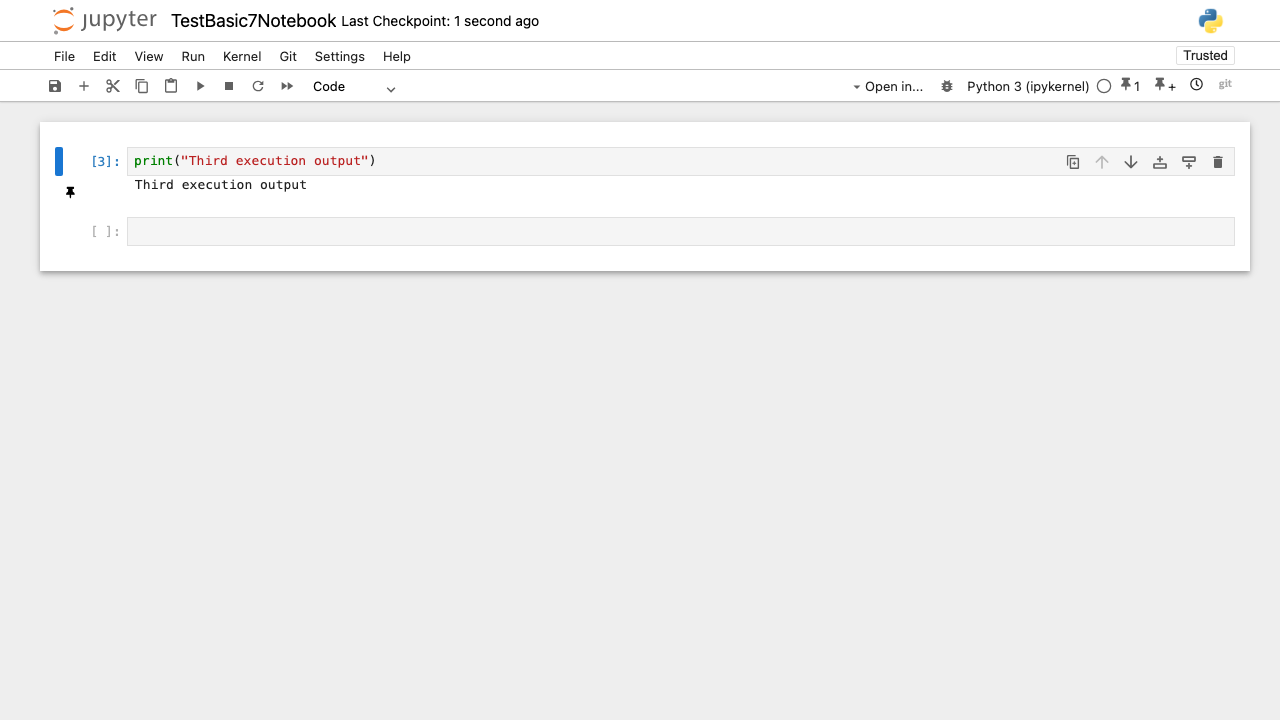

In [19]:
async def _step_save_notebook(page):
    await save_notebook(page)
    print("✓ Notebook saved")

await run_pw(_step_save_notebook)

## Clean up

In [ ]:
await finish_pw_context()

In [21]:
!rm -fr {work_dir}